# 04. Confidence Intervals: Wald, Likelihood, and Bootstrap

The previous notebooks built the ingredients we need for interval estimation. Notebook 02 explained repeated-sample variability and asymptotics. Notebook 03 showed how the likelihood function ranks parameter values by support under a model. We put those ideas together and ask a more practical question:

**How should we construct an uncertainty interval for a quantity we actually care about?**

There is no single universal answer. Different interval families inherit different assumptions and fail in different ways. Wald intervals rely on local normal approximations. Likelihood intervals inherit a model-based likelihood geometry. Bootstrap intervals resample the empirical distribution and let the data approximate the estimator's sampling distribution directly.

In regular problems, these three approaches often look reassuringly similar. In stressed problems, especially rare-event proportions, they can diverge sharply. That divergence is not noise. It is one of the most important diagnostics an analyst can see.

## Learning Objectives

After working through this lecture, you should be able to:

1. State what a 95% confidence interval means in repeated-sample terms.
2. Construct and interpret Wald intervals from standard-error approximations.
3. Build profile-likelihood intervals using likelihood-ratio support.
4. Compute percentile bootstrap intervals from resampled data.
5. Compare interval families for a regular continuous target and for binomial risk measures.
6. Diagnose why Wald intervals can become unstable for rare events.
7. Explain why bootstrap intervals are helpful but not magically superior in every discrete problem.
8. Write a decision memo that compares interval evidence alongside the point estimate.

### Dataset and Experiment Design

The dataset is a synthetic support audit with continuous resolution times, binary SLA breaches, and rare critical failures. Each row is one ticket drawn from a larger operating process. The examples use this structure because interval behavior depends strongly on the estimand: a mean, a common proportion, and a rare-event proportion do not have the same uncertainty geometry.

The experiment compares several interval families on the same operational targets. Wald intervals use local normal approximations, likelihood intervals use model support, and bootstrap intervals resample the observed data. We also stress the procedures with rare events and moderate sample sizes to show where intervals diverge.

The purpose is not to memorize one interval as universally best. The purpose is to teach students to match the interval method to the data scale, sample size, and decision threshold.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 160)
np.random.seed(2026)

CHI2_CUTOFF_95 = 3.841458820694124


def make_support_population(n=60_000, seed=310, sla_minutes=60):
    """
    Construct the support population object used in this lecture.
    
    Parameters:
        n: Number of observations, rows, or simulated units to generate.
        seed: Random seed used to make the simulation or resampling reproducible.
        sla_minutes: Decision or statistical threshold used to define the target, interval, or rule.
    
    Returns:
        A pandas DataFrame representing the simulated support population, including covariates, operational outcomes, and ground-truth targets used later for inference checks.
    
    Idea:
        Create a known synthetic population so sample estimates, intervals, likelihoods, and inference procedures can be checked against ground truth.
    """
    rng = np.random.default_rng(seed)

    seller_tier = rng.choice(['growth', 'enterprise'], size=n, p=[0.72, 0.28])
    severity = rng.choice(['routine', 'complex', 'urgent'], size=n, p=[0.55, 0.32, 0.13])
    region = rng.choice(['North', 'South', 'West', 'Central'], size=n, p=[0.24, 0.22, 0.29, 0.25])
    channel = rng.choice(['chat', 'email', 'phone'], size=n, p=[0.44, 0.31, 0.25])

    queue_pressure = np.clip(
        rng.normal(0.0, 0.85, n)
        + np.where(region == 'West', 0.18, 0.0)
        + np.where(region == 'South', 0.08, 0.0),
        -1.5,
        2.8,
    )
    analyst_tenure_years = rng.gamma(shape=3.5, scale=1.3, size=n)
    automation_assist = rng.binomial(
        1,
        p=np.where(severity == 'routine', 0.72, np.where(severity == 'complex', 0.48, 0.22)),
        size=n,
    )

    severity_base = {'routine': 30, 'complex': 48, 'urgent': 70}
    tier_effect = {'growth': -2, 'enterprise': 4}
    channel_effect = {'chat': -5, 'email': 2, 'phone': 7}
    region_effect = {'North': -2, 'South': 2, 'West': 4, 'Central': 0}

    service_noise = rng.normal(0, 7, n) + rng.gamma(2.3, 2.6, n)

    resolution_minutes = (
        np.vectorize(severity_base.get)(severity)
        + np.vectorize(tier_effect.get)(seller_tier)
        + np.vectorize(channel_effect.get)(channel)
        + np.vectorize(region_effect.get)(region)
        + 5.8 * queue_pressure
        - 1.8 * analyst_tenure_years
        - 6.0 * automation_assist
        + service_noise
    )
    resolution_minutes = np.clip(resolution_minutes, 5, None)

    sla_breach = (resolution_minutes > sla_minutes).astype(int)
    critical_failure = (resolution_minutes > 90).astype(int)
    cost_per_ticket = 14 + 0.72 * resolution_minutes + 18 * sla_breach + 0.12 * np.maximum(resolution_minutes - sla_minutes, 0) ** 1.1

    return pd.DataFrame(
        {
            'seller_tier': seller_tier,
            'severity': severity,
            'region': region,
            'channel': channel,
            'queue_pressure': queue_pressure,
            'analyst_tenure_years': analyst_tenure_years,
            'automation_assist': automation_assist,
            'resolution_minutes': resolution_minutes,
            'sla_breach': sla_breach,
            'critical_failure': critical_failure,
            'cost_per_ticket': cost_per_ticket,
        }
    )


def mean_interval_wald(values, z=1.96):
    """
    Compute a Wald confidence interval for a sample mean.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        z: Normal critical value or z-score used in the interval or tail-probability calculation.
    
    Returns:
        A tuple containing the sample mean, the Wald interval endpoints, and the estimated standard error.
    
    Idea:
        Use an estimate plus a standard-error margin as the simplest interval construction, useful as a baseline and as a warning about approximation limits.
    """
    arr = np.asarray(values)
    estimate = arr.mean()
    se = arr.std(ddof=1) / np.sqrt(len(arr))
    return estimate, (estimate - z * se, estimate + z * se), se


def mean_interval_profile_likelihood(values, cutoff=CHI2_CUTOFF_95, num=4000):
    """
    Compute a profile-likelihood confidence interval for a normal mean.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        cutoff: Decision or statistical threshold used to define the target, interval, or rule.
        num: Number of draws or grid points used in the numerical approximation.
    
    Returns:
        A tuple containing the maximum-likelihood mean estimate and the profile-likelihood interval endpoints.
    
    Idea:
        Invert the likelihood profile to find mean values still compatible with the observed data at a chosen evidence level.
    """
    arr = np.asarray(values)
    n = len(arr)
    mu_hat = arr.mean()
    sse_hat = np.sum((arr - mu_hat) ** 2)
    se_like = np.sqrt(sse_hat / n) / np.sqrt(n)
    mu_grid = np.linspace(mu_hat - 4 * se_like, mu_hat + 4 * se_like, num)
    rss = sse_hat + n * (mu_grid - mu_hat) ** 2
    loglik = -n / 2 * (1 + np.log(2 * np.pi) + np.log(rss / n))
    mask = 2 * (loglik.max() - loglik) <= cutoff
    return mu_hat, (mu_grid[mask][0], mu_grid[mask][-1])


def mean_interval_bootstrap(values, reps=4000, seed=0):
    """
    Compute a bootstrap confidence interval for a sample mean.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        reps: Number of repeated samples, bootstrap draws, or simulation replications.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A tuple containing the observed sample mean and the bootstrap percentile interval endpoints.
    
    Idea:
        Use resampling to form a mean interval without relying entirely on the normal approximation.
    """
    arr = np.asarray(values)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(arr), size=(reps, len(arr)))
    boot = arr[idx].mean(axis=1)
    return arr.mean(), tuple(np.quantile(boot, [0.025, 0.975]))


def proportion_interval_wald(values, z=1.96):
    """
    Compute a Wald confidence interval for a sample proportion.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        z: Normal critical value or z-score used in the interval or tail-probability calculation.
    
    Returns:
        A tuple containing the observed proportion, the Wald interval endpoints, and the estimated standard error.
    
    Idea:
        Construct the textbook Wald interval so its convenience and fragility can be compared with better alternatives.
    """
    arr = np.asarray(values)
    estimate = arr.mean()
    se = np.sqrt(estimate * (1 - estimate) / len(arr))
    return estimate, (estimate - z * se, estimate + z * se), se


def proportion_interval_profile_likelihood(values, cutoff=CHI2_CUTOFF_95, num=5000, upper=None):
    """
    Compute a profile-likelihood confidence interval for a binomial proportion.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        cutoff: Decision or statistical threshold used to define the target, interval, or rule.
        num: Number of draws or grid points used in the numerical approximation.
        upper: Upper edge of the probability grid used to search for likelihood-supported values.
    
    Returns:
        A tuple containing the observed proportion and the profile-likelihood interval endpoints.
    
    Idea:
        Invert the binomial likelihood to obtain a proportion interval grounded in relative evidence.
    """
    arr = np.asarray(values)
    x = int(arr.sum())
    n = len(arr)
    p_hat = arr.mean()
    if upper is None:
        upper = min(0.5, max(0.03, p_hat + 0.08, p_hat + 5 * np.sqrt(max(p_hat * (1 - p_hat) / n, 1e-6))))
    p_grid = np.linspace(1e-6, upper, num)
    log_p = np.log(np.clip(p_grid, 1e-12, 1 - 1e-12))
    log_q = np.log(np.clip(1 - p_grid, 1e-12, 1 - 1e-12))
    loglik = x * log_p + (n - x) * log_q
    mask = 2 * (loglik.max() - loglik) <= cutoff
    return p_hat, (p_grid[mask][0], p_grid[mask][-1])


def proportion_interval_bootstrap(values, reps=5000, seed=0):
    """
    Compute a bootstrap confidence interval for a binomial proportion.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        reps: Number of repeated samples, bootstrap draws, or simulation replications.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A tuple containing the observed proportion and the bootstrap percentile interval endpoints.
    
    Idea:
        Use resampling to express uncertainty in an observed event rate without forcing symmetry around the estimate.
    """
    arr = np.asarray(values)
    n = len(arr)
    p_hat = arr.mean()
    rng = np.random.default_rng(seed)
    boot = rng.binomial(n, p_hat, size=reps) / n
    return p_hat, tuple(np.quantile(boot, [0.025, 0.975]))


def interval_width(interval):
    """
    Compute the width of an interval for method comparison.
    
    Parameters:
        interval: Interval object or confidence-interval information used by the helper.
    
    Returns:
        The numerical width of the interval, computed as upper endpoint minus lower endpoint.
    
    Idea:
        Measure interval width as a direct summary of precision; narrower intervals are not automatically better unless coverage remains credible.
    """
    return interval[1] - interval[0]


def plot_interval_panel(ax, summary_df, truth, xlabel, threshold=None, x_as_percent=False):
    """
    Create a horizontal interval comparison panel.
    
    Parameters:
        ax: Matplotlib axis where the interval panel should be drawn.
        summary_df: DataFrame with one row per interval method and columns for method, estimate, lower, upper, and color.
        truth: Hidden population value used as the reference line for checking whether each interval covers the target.
        xlabel: Label describing the horizontal scale of the interval plot.
        threshold: Optional decision threshold to draw alongside the interval estimates.
        x_as_percent: Whether estimates and interval endpoints should be multiplied by 100 before plotting.
    
    Returns:
        Nothing. The function draws the interval estimates, point estimates, truth line, and optional decision references on the supplied axis.
    
    Idea:
        Put several interval procedures on one common scale so agreement, width, boundary problems, and decision-threshold overlap are visible at a glance.
    """
    methods = list(summary_df['method'])
    y_positions = np.arange(len(methods))[::-1]
    scale = 100 if x_as_percent else 1
    x_values = []

    for y_pos, (_, row) in zip(y_positions, summary_df.iterrows()):
        ax.hlines(y_pos, scale * row['lower'], scale * row['upper'], color=row['color'], linewidth=3)
        ax.plot(scale * row['estimate'], y_pos, 'o', color=row['color'], markersize=7)
        x_values.extend([scale * row['lower'], scale * row['upper'], scale * row['estimate']])

    ax.axvline(scale * truth, color='black', linestyle='--', linewidth=1.4, label='Hidden population truth')
    x_values.append(scale * truth)
    if threshold is not None:
        ax.axvline(scale * threshold, color='#E45756', linestyle=':', linewidth=1.5, label='Decision threshold')
        x_values.append(scale * threshold)

    x_min = min(x_values)
    x_max = max(x_values)
    if x_min < 0 < x_max:
        ax.axvline(0, color='#6B6B6B', linestyle='-.', linewidth=1.25, label='Feasible lower boundary')
        x_values.append(0)
        x_min = min(x_values)
        x_max = max(x_values)

    padding = 0.06 * (x_max - x_min if x_max > x_min else 1)
    ax.set_xlim(x_min - padding, x_max + padding)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(methods)
    ax.set_xlabel(xlabel)
    if threshold is None:
        ax.legend(loc='best')
    else:
        ax.legend(loc='best')

## 1. What a Confidence Interval Means

A 95% confidence interval is a statement about a **procedure**, not a posterior probability statement about a fixed unknown parameter. Formally, if $L(Y)$ and $U(Y)$ are interval endpoints computed from a random sample $Y$, then the target property is

$$
P_\theta \{L(Y) \le \theta \le U(Y)\} \approx 0.95.
$$

The word “approximately” matters in practice. Coverage depends on the interval construction, the sample size, and the target parameter.

We compare three interval families:

1. **Wald intervals**: estimate $\pm$ critical value times standard error.
2. **Likelihood intervals**: values whose profile likelihood remains sufficiently close to the maximum.
3. **Bootstrap percentile intervals**: empirical quantiles from the resampled estimator distribution.

Each family encodes a different approximation strategy. The interesting question is not which one is universally best. It is **when each one is trustworthy enough for the target at hand**.

## 2. Setup: Three Targets With Different Degrees of Difficulty

We keep the same synthetic support-operation system used in the earlier notebooks. This time we focus on three targets:

- the mean resolution time, a regular continuous quantity,
- the enterprise-ticket SLA breach rate, a moderate binomial risk,
- the critical-failure rate, a rare-event binomial risk.

These targets are intentionally chosen to create a spectrum. If the interval families behave similarly for the first target and differently for the third, that is not a contradiction. It is the whole lesson.

In [2]:
# Build a summary table that supports the interpretation in the surrounding notes.
sla_minutes = 60
population = make_support_population(n=60_000, seed=310, sla_minutes=sla_minutes)
audit_sample = population.sample(n=1_000, random_state=2026).reset_index(drop=True)
enterprise_audit = audit_sample.query("seller_tier == 'enterprise'").reset_index(drop=True)

population_mean = population['resolution_minutes'].mean()
enterprise_truth = population.query("seller_tier == 'enterprise'")['sla_breach'].mean()
critical_truth = population['critical_failure'].mean()

setup_table = pd.DataFrame(
    [
        {
            'target': 'Mean resolution time',
            'sample_used': 'All audited tickets',
            'observed_estimate': f"{audit_sample['resolution_minutes'].mean():0.2f} minutes",
            'hidden_population_truth': f"{population_mean:0.2f} minutes",
            'effective_sample_size': f"{len(audit_sample)}",
        },
        {
            'target': 'Enterprise SLA breach rate',
            'sample_used': 'Enterprise audited tickets only',
            'observed_estimate': f"{100 * enterprise_audit['sla_breach'].mean():0.2f}%",
            'hidden_population_truth': f"{100 * enterprise_truth:0.2f}%",
            'effective_sample_size': f"{len(enterprise_audit)}",
        },
        {
            'target': 'Critical failure rate (> 90 min)',
            'sample_used': 'All audited tickets',
            'observed_estimate': f"{100 * audit_sample['critical_failure'].mean():0.3f}%",
            'hidden_population_truth': f"{100 * critical_truth:0.3f}%",
            'effective_sample_size': f"{len(audit_sample)}",
        },
    ]
)
smart_display(setup_table)

,target,sample_used,observed_estimate,hidden_population_truth,effective_sample_size
0,Mean resolution time,All audited tickets,37.33 minutes,36.79 minutes,1000
1,Enterprise SLA breach rate,Enterprise audited tickets only,18.37%,17.21%,294
2,Critical failure rate (> 90 min),All audited tickets,0.300%,0.455%,1000


The three targets are not equally hard.

- The mean resolution time uses 1,000 observations and averages over a continuous outcome. That is a friendly setting for many interval approximations.
- The enterprise breach rate is still reasonably regular, but the effective sample size is smaller because the estimate is based only on enterprise tickets.
- The critical-failure rate is intrinsically difficult because the event is rare. Even with 1,000 audited tickets, only a handful of failures may be observed.

Keep that lens in mind: interval performance is a property of the **target, the effective sample size, and the interval formula together**.

## 3. A Regular Continuous Target: Mean Resolution Time

For a regular continuous target, we expect the interval families to agree closely.

- The **Wald interval** uses the standard-error approximation

$$
\bar{Y} \pm 1.96 \frac{s}{\sqrt{n}}.
$$

- The **likelihood interval** profiles the normal likelihood over $\mu$ and keeps values satisfying

$$
2\{\ell(\hat{\mu}) - \ell(\mu)\} \le \chi^2_{1,0.95}.
$$

- The **bootstrap interval** uses the 2.5% and 97.5% quantiles of the resampled mean.

If the three intervals nearly coincide, that is a reassuring sign that this is a regular inference problem with limited fragility.

,method,interval,width
0,Wald,"[36.16, 38.50]",2.34
1,Likelihood,"[36.16, 38.50]",2.34
2,Bootstrap,"[36.14, 38.50]",2.36


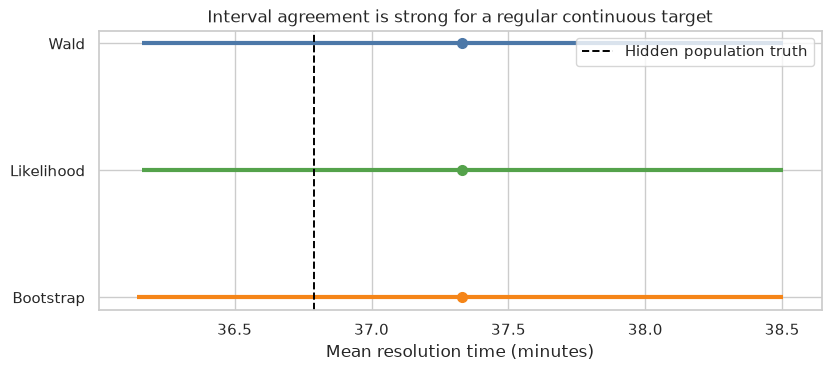

In [3]:
# Compare mean-resolution intervals across Wald, profile-likelihood, and bootstrap constructions.
mean_wald_est, mean_wald_interval, mean_wald_se = mean_interval_wald(audit_sample['resolution_minutes'])
_, mean_like_interval = mean_interval_profile_likelihood(audit_sample['resolution_minutes'])
_, mean_boot_interval = mean_interval_bootstrap(audit_sample['resolution_minutes'], reps=4000, seed=901)

mean_interval_df = pd.DataFrame(
    [
        {
            'method': 'Wald',
            'estimate': mean_wald_est,
            'lower': mean_wald_interval[0],
            'upper': mean_wald_interval[1],
            'interval': f"[{mean_wald_interval[0]:0.2f}, {mean_wald_interval[1]:0.2f}]",
            'width': f"{interval_width(mean_wald_interval):0.2f}",
            'color': '#4C78A8',
        },
        {
            'method': 'Likelihood',
            'estimate': mean_wald_est,
            'lower': mean_like_interval[0],
            'upper': mean_like_interval[1],
            'interval': f"[{mean_like_interval[0]:0.2f}, {mean_like_interval[1]:0.2f}]",
            'width': f"{interval_width(mean_like_interval):0.2f}",
            'color': '#54A24B',
        },
        {
            'method': 'Bootstrap',
            'estimate': mean_wald_est,
            'lower': mean_boot_interval[0],
            'upper': mean_boot_interval[1],
            'interval': f"[{mean_boot_interval[0]:0.2f}, {mean_boot_interval[1]:0.2f}]",
            'width': f"{interval_width(mean_boot_interval):0.2f}",
            'color': '#F58518',
        },
    ]
)
smart_display(mean_interval_df[['method', 'interval', 'width']])

fig, ax = plt.subplots(figsize=(8.2, 3.6), constrained_layout=True)
plot_interval_panel(ax, mean_interval_df, truth=population_mean, xlabel='Mean resolution time (minutes)')
ax.set_title('Interval agreement is strong for a regular continuous target')
plt.show()

The three intervals are nearly identical. That is exactly what we hope to see in a regular problem.

The takeaway is not that one family “won.” The more important lesson is that when different inferential constructions agree, the analyst can be more confident that the conclusion is driven by the data with limited dependence on one fragile approximation choice.

This is also why the mean often feels easy compared with risk measures for rare events. The estimator is regular, the sampling distribution is stable, and the model geometry is benign.

## 4. A Moderate Binomial Risk: Enterprise SLA Breach Rate

Now consider the enterprise breach rate. This is still a proportion, but not an extreme one. The effective sample size is 294 enterprise tickets with 54 observed breaches.

For a binomial proportion, the three interval constructions are conceptually similar to the previous section but operationally different:

- the **Wald interval** uses the plug-in standard error $\sqrt{\hat{p}(1-\hat{p})/n}$,
- the **likelihood interval** inverts the Bernoulli likelihood-ratio support,
- the **bootstrap interval** resamples the empirical Bernoulli distribution.

This is a good middle-case example because the target is important for the leadership decision, but the problem is not so extreme that every approximation collapses.

,method,interval,width
0,Wald,"[13.94%, 22.79%]",8.85%
1,Likelihood,"[14.23%, 23.06%]",8.83%
2,Bootstrap,"[13.95%, 22.79%]",8.84%


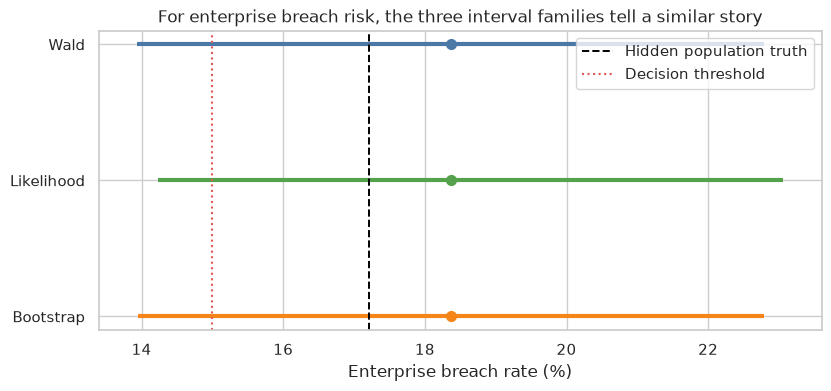

In [4]:
# Compare enterprise breach-rate intervals against the leadership decision threshold.
enterprise_wald_est, enterprise_wald_interval, enterprise_wald_se = proportion_interval_wald(enterprise_audit['sla_breach'])
_, enterprise_like_interval = proportion_interval_profile_likelihood(enterprise_audit['sla_breach'], upper=0.35)
_, enterprise_boot_interval = proportion_interval_bootstrap(enterprise_audit['sla_breach'], reps=5000, seed=902)

enterprise_interval_df = pd.DataFrame(
    [
        {
            'method': 'Wald',
            'estimate': enterprise_wald_est,
            'lower': enterprise_wald_interval[0],
            'upper': enterprise_wald_interval[1],
            'interval': f"[{100 * enterprise_wald_interval[0]:0.2f}%, {100 * enterprise_wald_interval[1]:0.2f}%]",
            'width': f"{100 * interval_width(enterprise_wald_interval):0.2f}%",
            'color': '#4C78A8',
        },
        {
            'method': 'Likelihood',
            'estimate': enterprise_wald_est,
            'lower': enterprise_like_interval[0],
            'upper': enterprise_like_interval[1],
            'interval': f"[{100 * enterprise_like_interval[0]:0.2f}%, {100 * enterprise_like_interval[1]:0.2f}%]",
            'width': f"{100 * interval_width(enterprise_like_interval):0.2f}%",
            'color': '#54A24B',
        },
        {
            'method': 'Bootstrap',
            'estimate': enterprise_wald_est,
            'lower': enterprise_boot_interval[0],
            'upper': enterprise_boot_interval[1],
            'interval': f"[{100 * enterprise_boot_interval[0]:0.2f}%, {100 * enterprise_boot_interval[1]:0.2f}%]",
            'width': f"{100 * interval_width(enterprise_boot_interval):0.2f}%",
            'color': '#F58518',
        },
    ]
)
smart_display(enterprise_interval_df[['method', 'interval', 'width']])

fig, ax = plt.subplots(figsize=(8.2, 3.8), constrained_layout=True)
plot_interval_panel(ax, enterprise_interval_df, truth=enterprise_truth, xlabel='Enterprise breach rate (%)', threshold=0.15, x_as_percent=True)
ax.set_title('For enterprise breach risk, the three interval families tell a similar story')
plt.show()

Here again the three intervals are quite close. That is reassuring, but the decision implication is subtle.

All three intervals straddle the 15% leadership threshold. So although the point estimate is above 15%, the threshold is not completely incompatible with the data. At the same time, none of the intervals support a strong claim that the true enterprise breach rate is already safely below 15%.

This is a classic example of why interval thinking is more honest than threshold chasing. The data do not say “definitely yes” or “definitely no.” They say the operational risk is still uncertain and centered above the desired target.

## 5. A Rare-Event Risk: Critical Failure Rate

Now the problem becomes harder. The critical-failure rate is rare, and in the observed audit only 3 failures appear among 1,000 tickets.

This is exactly where Brown, Cai, and DasGupta (2001) warn that the ordinary Wald interval can behave erratically for binomial proportions. Bootstrap intervals are often helpful, but for discrete rare-event problems they can still inherit awkward behavior from the underlying empirical distribution. The likelihood interval also has limits, and it often respects the geometry of the parameter space more naturally.

,method,interval,width,diagnostic
0,Wald,"[-0.039%, 0.639%]",0.678%,Lower bound falls below zero.
1,Likelihood,"[0.075%, 0.776%]",0.701%,Respects the boundary at zero and remains asymmetric.
2,Bootstrap,"[0.000%, 0.700%]",0.700%,Snaps to zero on the lower end because resamples often contain no failures.


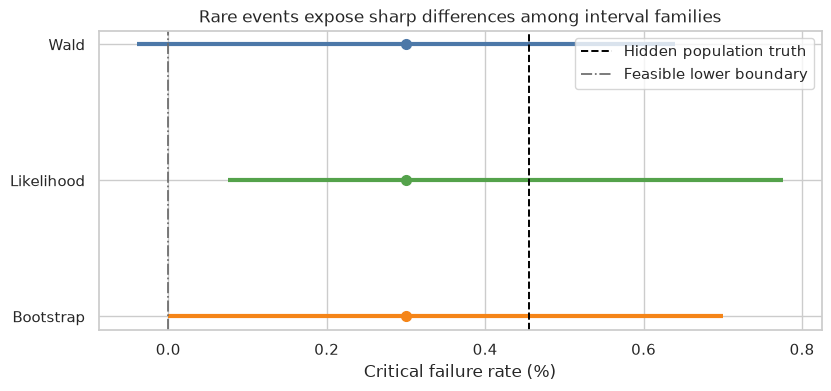

In [5]:
# Compare rare-event intervals and make boundary problems visible.
critical_wald_est, critical_wald_interval, critical_wald_se = proportion_interval_wald(audit_sample['critical_failure'])
_, critical_like_interval = proportion_interval_profile_likelihood(audit_sample['critical_failure'], upper=0.02)
_, critical_boot_interval = proportion_interval_bootstrap(audit_sample['critical_failure'], reps=5000, seed=903)

critical_interval_df = pd.DataFrame(
    [
        {
            'method': 'Wald',
            'estimate': critical_wald_est,
            'lower': critical_wald_interval[0],
            'upper': critical_wald_interval[1],
            'interval': f"[{100 * critical_wald_interval[0]:0.3f}%, {100 * critical_wald_interval[1]:0.3f}%]",
            'width': f"{100 * interval_width(critical_wald_interval):0.3f}%",
            'diagnostic': 'Lower bound falls below zero.',
            'color': '#4C78A8',
        },
        {
            'method': 'Likelihood',
            'estimate': critical_wald_est,
            'lower': critical_like_interval[0],
            'upper': critical_like_interval[1],
            'interval': f"[{100 * critical_like_interval[0]:0.3f}%, {100 * critical_like_interval[1]:0.3f}%]",
            'width': f"{100 * interval_width(critical_like_interval):0.3f}%",
            'diagnostic': 'Respects the boundary at zero and remains asymmetric.',
            'color': '#54A24B',
        },
        {
            'method': 'Bootstrap',
            'estimate': critical_wald_est,
            'lower': critical_boot_interval[0],
            'upper': critical_boot_interval[1],
            'interval': f"[{100 * critical_boot_interval[0]:0.3f}%, {100 * critical_boot_interval[1]:0.3f}%]",
            'width': f"{100 * interval_width(critical_boot_interval):0.3f}%",
            'diagnostic': 'Snaps to zero on the lower end because resamples often contain no failures.',
            'color': '#F58518',
        },
    ]
)
smart_display(critical_interval_df[['method', 'interval', 'width', 'diagnostic']])

fig, ax = plt.subplots(figsize=(8.2, 3.8), constrained_layout=True)
plot_interval_panel(ax, critical_interval_df, truth=critical_truth, xlabel='Critical failure rate (%)', x_as_percent=True)
ax.set_title('Rare events expose sharp differences among interval families')
plt.show()

This is the first genuinely stressed target in the notebook.

- The **Wald interval** produces an impossible negative lower bound.
- The **bootstrap percentile interval** avoids negativity but collapses to zero on the lower end because many bootstrap resamples contain no critical failures at all.
- The **likelihood interval** is asymmetric and boundary-respecting, which is often more faithful to the actual geometry of the problem.

The main lesson is not that bootstrap or likelihood always dominates. It is that the interval family becomes part of the substantive story when the target is rare and discrete.

## 6. Coverage and Pathologies Across Repeated Audits

The observed audit is just one sample. To compare interval procedures properly, we should ask how they behave over many repeated samples.

We will study three scenarios:

1. enterprise breach risk with $n = 300$,
2. critical-failure risk with $n = 200$,
3. critical-failure risk with $n = 1000$.

For each scenario we compare empirical coverage, median interval width, and common pathologies such as negative lower bounds or lower bounds that degenerate to zero.

,scenario,method,coverage,median_width,negative_lower_bounds,lower_bound_equal_to_zero
0,Enterprise breach (n = 300),Wald,93.7%,8.57%,0.0%,0.0%
1,Enterprise breach (n = 300),Likelihood,94.0%,8.53%,0.0%,0.0%
2,Enterprise breach (n = 300),Bootstrap,94.2%,8.51%,0.0%,0.0%
3,Critical failure (n = 200),Wald,57.3%,1.96%,56.2%,42.7%
4,Critical failure (n = 200),Likelihood,98.8%,2.15%,0.0%,0.0%
5,Critical failure (n = 200),Bootstrap,56.2%,1.50%,0.0%,98.8%
6,Critical failure (n = 1000),Wald,94.7%,0.78%,31.0%,1.0%
7,Critical failure (n = 1000),Likelihood,93.7%,0.80%,0.0%,0.0%
8,Critical failure (n = 1000),Bootstrap,94.0%,0.80%,0.0%,32.7%


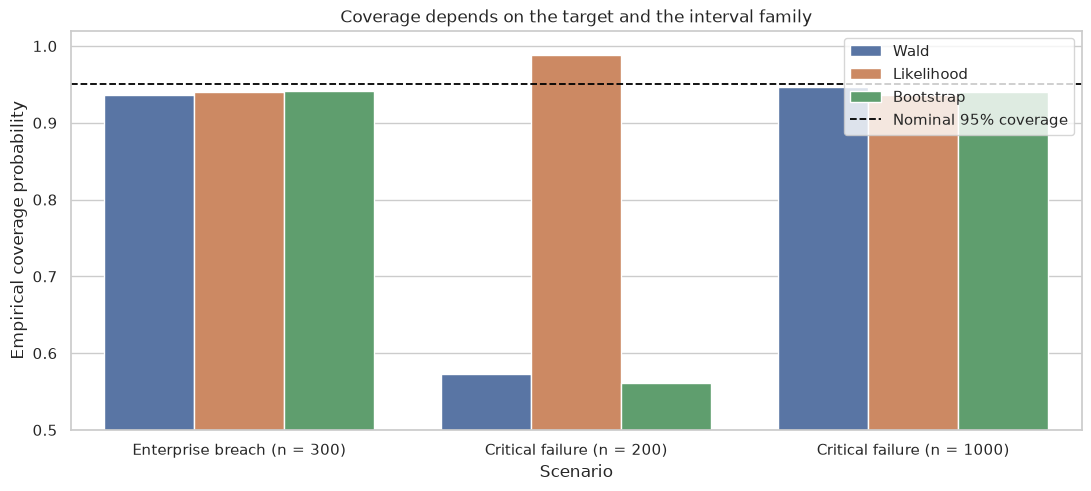

In [6]:
# Simulate repeated audits to estimate coverage and common interval pathologies.
rng = np.random.default_rng(904)
scenario_specs = [
    ('Enterprise breach (n = 300)', enterprise_truth, 300, np.linspace(1e-4, 0.40, 3000)),
    ('Critical failure (n = 200)', critical_truth, 200, np.linspace(1e-6, 0.08, 3000)),
    ('Critical failure (n = 1000)', critical_truth, 1000, np.linspace(1e-6, 0.03, 3000)),
]

coverage_rows = []
plot_rows = []

for scenario, truth, n, p_grid in scenario_specs:
    reps = 600
    counts = rng.binomial(n, truth, size=reps)
    p_hat = counts / n

    wald_low = p_hat - 1.96 * np.sqrt(np.maximum(p_hat * (1 - p_hat) / n, 0))
    wald_high = p_hat + 1.96 * np.sqrt(np.maximum(p_hat * (1 - p_hat) / n, 0))

    profile_low = []
    profile_high = []
    log_p = np.log(np.clip(p_grid, 1e-12, 1 - 1e-12))
    log_q = np.log(np.clip(1 - p_grid, 1e-12, 1 - 1e-12))
    for x in counts:
        loglik = x * log_p + (n - x) * log_q
        mask = 2 * (loglik.max() - loglik) <= CHI2_CUTOFF_95
        profile_low.append(p_grid[mask][0])
        profile_high.append(p_grid[mask][-1])
    profile_low = np.array(profile_low)
    profile_high = np.array(profile_high)

    boot_draws = rng.binomial(n, p_hat[:, None], size=(reps, 1500)) / n
    boot_low = np.quantile(boot_draws, 0.025, axis=1)
    boot_high = np.quantile(boot_draws, 0.975, axis=1)

    for method, low, high in [
        ('Wald', wald_low, wald_high),
        ('Likelihood', profile_low, profile_high),
        ('Bootstrap', boot_low, boot_high),
    ]:
        coverage = np.mean((low <= truth) & (truth <= high))
        median_width = np.median(high - low)
        negative_lower = np.mean(low < 0)
        zero_lower = np.mean(low == 0)
        coverage_rows.append(
            {
                'scenario': scenario,
                'method': method,
                'coverage': f"{100 * coverage:0.1f}%",
                'median_width': f"{100 * median_width:0.2f}%",
                'negative_lower_bounds': f"{100 * negative_lower:0.1f}%",
                'lower_bound_equal_to_zero': f"{100 * zero_lower:0.1f}%",
            }
        )
        plot_rows.append(
            {
                'scenario': scenario,
                'method': method,
                'coverage_value': coverage,
            }
        )

coverage_table = pd.DataFrame(coverage_rows)
smart_display(coverage_table)

coverage_plot = pd.DataFrame(plot_rows)
fig, ax = plt.subplots(figsize=(10.8, 4.8), constrained_layout=True)
sns.barplot(data=coverage_plot, x='scenario', y='coverage_value', hue='method', ax=ax)
ax.axhline(0.95, color='black', linestyle='--', linewidth=1.3, label='Nominal 95% coverage')
ax.set_title('Coverage depends on the target and the interval family')
ax.set_xlabel('Scenario')
ax.set_ylabel('Empirical coverage probability')
ax.set_ylim(0.50, 1.02)
ax.legend(loc='upper right')
plt.xticks(rotation=0)
plt.show()

The repeated-sample comparison reveals the real tradeoffs.

- For the enterprise breach rate, all three methods perform similarly and all are close to nominal 95% coverage.
- For the rare critical-failure rate with $n = 200$, the Wald interval fails badly and the bootstrap percentile interval also struggles because the empirical resampling distribution is heavily zero-inflated. The profile-likelihood interval is much more conservative here.
- For the rare critical-failure rate with $n = 1000$, all methods improve, but Wald intervals still frequently dip below zero and bootstrap intervals often pin their lower bound at zero.

This is a useful reminder that confidence intervals are procedures whose repeated-sample behavior has to be checked, especially when events are rare. The method itself becomes part of the inferential judgment.

## 7. Decision Memo Using Interval Evidence

Leadership is still considering a premium enterprise support promise, but only if the enterprise SLA breach rate is credibly below 15%.

We now have three interval summaries for the same target. A responsible memo should not cherry-pick the one that looks most convenient. It should report the agreement across methods and explain what that agreement does, and does not, justify.

In [7]:
# Convert the interval summaries into a decision memo without cherry-picking methods.
threshold = 0.15

if all(interval[1] < threshold for interval in [enterprise_wald_interval, enterprise_like_interval, enterprise_boot_interval]):
    recommendation = 'Proceed with the premium enterprise support promise.'
    interpretation = 'All three interval families place the enterprise breach rate below the decision threshold.'
elif enterprise_wald_est < threshold:
    recommendation = 'Continue the pilot before making the promise externally.'
    interpretation = 'The point estimate is below threshold, but the interval evidence still extends above it.'
else:
    recommendation = 'Do not advertise a sub-15% enterprise breach promise yet.'
    interpretation = 'The point estimate is above threshold, and every interval family still includes values above the leadership target.'

memo = (
    f"### Decision Memo\n\n"
    f"**Recommendation:** {recommendation}\n\n"
    f"**Observed enterprise estimate:** **{100 * enterprise_wald_est:0.2f}%** breach rate based on **{len(enterprise_audit)}** enterprise tickets.\n\n"
    f"**Interval evidence:**\n\n"
    f"- Wald 95% interval: **[{100 * enterprise_wald_interval[0]:0.2f}%, {100 * enterprise_wald_interval[1]:0.2f}%]**\n"
    f"- Likelihood 95% interval: **[{100 * enterprise_like_interval[0]:0.2f}%, {100 * enterprise_like_interval[1]:0.2f}%]**\n"
    f"- Bootstrap 95% interval: **[{100 * enterprise_boot_interval[0]:0.2f}%, {100 * enterprise_boot_interval[1]:0.2f}%]**\n"
    f"- Leadership threshold: **15.0%**\n\n"
    f"**Interpretation:** {interpretation}\n\n"
    f"The important point is that the interval families broadly agree. That agreement makes the inferential conclusion more robust: the current audit does not justify claiming that enterprise breach risk is already safely below the target. Confidence intervals should be treated as uncertainty summaries, not as binary certification devices (Greenland et al., 2016)."
)

display(Markdown(memo))

### Decision Memo

**Recommendation:** Do not advertise a sub-15% enterprise breach promise yet.

**Observed enterprise estimate:** **18.37%** breach rate based on **294** enterprise tickets.

**Interval evidence:**

- Wald 95% interval: **[13.94%, 22.79%]**
- Likelihood 95% interval: **[14.23%, 23.06%]**
- Bootstrap 95% interval: **[13.95%, 22.79%]**
- Leadership threshold: **15.0%**

**Interpretation:** The point estimate is above threshold, and every interval family still includes values above the leadership target.

The important point is that the interval families broadly agree. That agreement makes the inferential conclusion more robust: the current audit does not justify claiming that enterprise breach risk is already safely below the target. Confidence intervals should be treated as uncertainty summaries, not as binary certification devices (Greenland et al., 2016).

<!-- real-data-companion-course01 -->
## Real-Data Companion: Intervals for RAND HIE Utilization

Confidence intervals become more tangible when the outcome has real scale. RAND HIE gives us outpatient physician visits (`mdvis`), a count outcome with skew and many low values. That structure makes it useful because interval methods can be compared on a real measurement scale instead of as a purely algebraic exercise.

The companion studies several targets: the mean number of visits, a bootstrap interval for the mean, and a Wilson interval for the probability of at least one outpatient visit. These targets answer different stakeholder questions. The mean speaks to expected utilization, while the binary probability speaks to access or any-use behavior.

The experiment is intentionally modest. It does not estimate the full causal effect of insurance generosity. Instead, it uses real utilization data to show that interval choice depends on the estimand and measurement scale. A count mean, a binary proportion, and a skewed bootstrap distribution should not be reported as if they were interchangeable.

For clarity, the unit is a person-period record. The outcomes are outpatient visit count and any-visit status. The experiment compares interval procedures for different estimands so students can see how the data scale changes the uncertainty statement.

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

,target,method,estimate,lower,upper
0,Mean outpatient visits,t interval,2.860,2.798,2.923
1,Mean outpatient visits,bootstrap percentile,2.860,2.803,2.927
2,Any outpatient visit,Wilson proportion,0.688,0.681,0.694


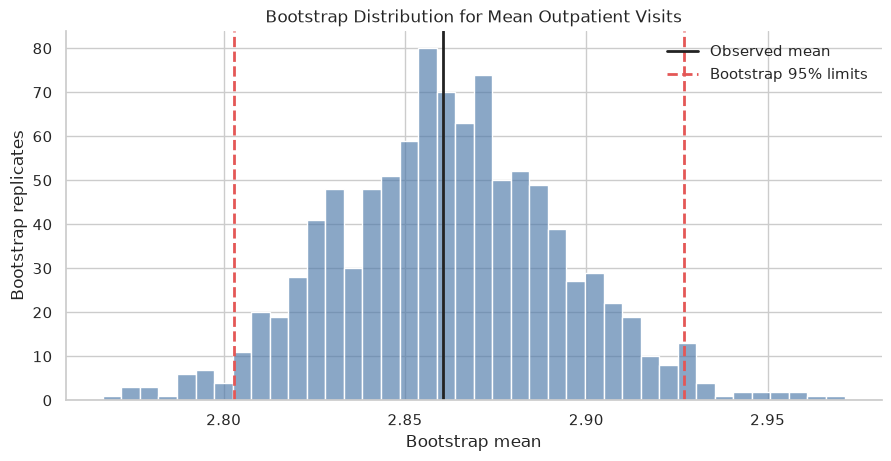

In [8]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    rng_real = np.random.default_rng(2026)
    rand_hie = load_statsmodels_randhie()
    visits = rand_hie["mdvis"].to_numpy()
    any_visit = visits > 0
    n = len(visits)

    mean_estimate = visits.mean()
    mean_se = visits.std(ddof=1) / np.sqrt(n)
    mean_wald = stats.t.interval(0.95, df=n - 1, loc=mean_estimate, scale=mean_se)

    bootstrap_means = np.array([
        rng_real.choice(visits, size=n, replace=True).mean()
        for _ in range(1_000)
    ])
    bootstrap_ci = np.quantile(bootstrap_means, [0.025, 0.975])

    wilson_ci = proportion_confint(any_visit.sum(), n, alpha=0.05, method="wilson")
    interval_table = pd.DataFrame(
        [
            {"target": "Mean outpatient visits", "method": "t interval", "estimate": mean_estimate, "lower": mean_wald[0], "upper": mean_wald[1]},
            {"target": "Mean outpatient visits", "method": "bootstrap percentile", "estimate": mean_estimate, "lower": bootstrap_ci[0], "upper": bootstrap_ci[1]},
            {"target": "Any outpatient visit", "method": "Wilson proportion", "estimate": any_visit.mean(), "lower": wilson_ci[0], "upper": wilson_ci[1]},
        ]
    )
    smart_display(interval_table.round(3))

    fig, ax = plt.subplots(figsize=(8.8, 4.5), constrained_layout=True)
    sns.histplot(bootstrap_means, bins=40, color="#4C78A8", alpha=0.65, ax=ax)
    ax.axvline(mean_estimate, color="#222222", linewidth=2, label="Observed mean")
    ax.axvline(bootstrap_ci[0], color="#E45756", linestyle="--", linewidth=2, label="Bootstrap 95% limits")
    ax.axvline(bootstrap_ci[1], color="#E45756", linestyle="--", linewidth=2)
    ax.set_title("Bootstrap Distribution for Mean Outpatient Visits")
    ax.set_xlabel("Bootstrap mean")
    ax.set_ylabel("Bootstrap replicates")
    ax.legend(frameon=False)
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "RAND Health Insurance Experiment",
        "https://www.statsmodels.org/stable/datasets/generated/randhie.html",
        "RUN_REAL_DATA_COMPANION",
    )

<!-- real-data-companion-course01 -->
The real-data intervals are uncertainty statements around clearly named targets. The mean visit count and the any-visit probability answer different operational questions: one describes expected utilization volume, while the other describes whether a patient used outpatient care at all.

The bootstrap distribution is centered near the observed mean, and its percentile limits are close to the ordinary $t$ interval. That agreement is reassuring, but it does not erase the skew and discreteness of the visit-count outcome. In a real analysis, this would be a reason to report the mean interval clearly while also checking count models, tail behavior, and design limitations before turning the interval into a policy recommendation.

## 8. What to Remember

1. A confidence interval is a repeated-sample procedure, not a posterior probability statement about a fixed parameter.
2. Wald intervals are easy to compute but rely on local normal approximations that can fail badly for rare-event proportions.
3. Likelihood intervals use model-based support geometry and often respect asymmetry and parameter boundaries more naturally.
4. Bootstrap intervals let the empirical distribution approximate sampling variation directly, but for discrete rare events they can still inherit degenerate behavior.
5. Agreement across interval families is informative in its own right: it suggests the inferential conclusion is not overly fragile to the construction method.
6. Disagreement across interval families is also informative: it signals that the target is hard, the sample is thin, or the approximation is stressed.
7. Good decision science compares interval procedures as part of the evidence and makes the preferred formula explicit.

The next notebook continues the inferential arc by moving from interval estimation to hypothesis testing, with a special focus on how to use tests without collapsing back into shallow $p < 0.05$ thinking.

## References

- Brown, L. D., Cai, T., & DasGupta, A. (2001). *Interval estimation for a binomial proportion*. *Statistical Science, 16*(2). [https://doi.org/10.1214/ss/1009213286](https://doi.org/10.1214/ss/1009213286)
- Efron, B. (1979). *Bootstrap methods: Another look at the jackknife*. *The Annals of Statistics, 7*(1). [https://doi.org/10.1214/aos/1176344552](https://doi.org/10.1214/aos/1176344552)
- Greenland, S., Senn, S. J., Rothman, K. J., Carlin, J. B., Poole, C., Goodman, S. N., & Altman, D. G. (2016). *Statistical tests, P values, confidence intervals, and power: a guide to misinterpretations*. *European Journal of Epidemiology, 31*(4), 337-350. [https://doi.org/10.1007/s10654-016-0149-3](https://doi.org/10.1007/s10654-016-0149-3)
- Wilks, S. S. (1938). *The large-sample distribution of the likelihood ratio for testing composite hypotheses*. *The Annals of Mathematical Statistics, 9*(1), 60-62. [https://doi.org/10.1214/aoms/1177732360](https://doi.org/10.1214/aoms/1177732360)